# Life from noise

## Self-replicating programs that emerge from a soup of random bytes

A walkthrough of **"Computational Life: How Well-formed, Self-replicating Programs
Emerge from Simple Interaction"** — Agüera y Arcas, Alakuijala, Evans, Laurie,
Mordvintsev, Niklasson, Randazzo & Versari
([arXiv:2406.19108](https://arxiv.org/abs/2406.19108)).

---

### The claim

The setup is almost trivially simple:

> Fill a few thousand 64-byte tapes with **uniform random noise**. Repeatedly pick
> two at random, glue them into one 128-byte program, run it, cut the result back
> into two tapes, put them back. Repeat.

And yet, after some thousands of rounds, the soup crosses a sharp phase transition
and fills with programs that **copy themselves**.

### What makes this surprising

There is deliberately none of the usual machinery:

- **no fitness function** — nothing scores or ranks the programs;
- **no selection** — nothing is culled, nothing is bred;
- **no goal** of any kind;
- **no hand-written ancestor** — unlike Tierra and Avida, which are *seeded* with a
  working replicator and so start with life already underway.

Programs change for exactly one reason: **they overwrite themselves and each other.**

### What you will see here

| § | Section | What happens |
|:-:|:--|:--|
| **1** | The language | Why plain Brainfuck *cannot* self-replicate, and the one change that fixes it |
| **2** | The replicator | The paper's discovered program, traced byte by byte as it copies itself |
| **3** | The soup | An interactive run you start yourself — and watch cross over |
| **4** | Verification | Proving it really replicates, plus two traps that give false answers |
| **5** | Further | Where the result generalises, and where it breaks down |

---

## 0 · Setup

Everything below runs against three files sitting next to this notebook:

- **`bff.py`** — the interpreter, written to be read;
- **`soup.c`** — the same interpreter in C, roughly 100× faster;
- **`soup.py`** — the experiment driver, which compiles `soup.c` on first use.

That C core is the difference between reaching the phase transition in **seconds**
rather than in an hour.

In [2]:
import sys, pathlib, collections, time, textwrap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import ipywidgets as W
from IPython.display import display, HTML

sys.path.insert(0, str(pathlib.Path.cwd()))
import bff
from soup import (Soup, high_order_entropy, render, dominant_kmer, COMPRESSOR, TAPE)

%matplotlib inline

# ---- design tokens -------------------------------------------------------
# Categorical hues validated for colour-vision deficiency as a 4-slot set
# (worst all-pairs CVD dE 9.2, normal-vision 16.3). Glyph labels are drawn on
# top of the marks as well, so colour never carries meaning alone.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE    = "#e1e0d9", "#fcfcfb"
ZERO_C, NOOP_C   = "#1a1a19", "#e8e7e1"
FAMILY_C = {"move": "#2a78d6", "arith": "#eb6834",
            "copy": "#1baf7a", "loop": "#4a3aa7"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.titlepad": 12, "figure.dpi": 110,
})

OPS   = "<>{}-+.,[]"
FAMILY = {**{c: "move" for c in "<>{}"}, **{c: "arith" for c in "+-"},
          **{c: "copy" for c in ".,"},  **{c: "loop" for c in "[]"}}
# 0 = true zero, 1..4 = instruction families, 5 = inert data
CLASS_OF_FAMILY = {"move": 1, "arith": 2, "copy": 3, "loop": 4}
TAPE_CMAP = ListedColormap([ZERO_C, FAMILY_C["move"], FAMILY_C["arith"],
                            FAMILY_C["copy"], FAMILY_C["loop"], NOOP_C])

def classify(b: int) -> int:
    if b == 0:
        return 0
    ch = chr(b)
    return CLASS_OF_FAMILY[FAMILY[ch]] if ch in FAMILY else 5

def classify_row(buf) -> np.ndarray:
    return np.array([classify(b) for b in buf], dtype=np.uint8)

def glyph(b: int) -> str:
    """The character to print for a byte: opcodes as themselves, 0 as a dot."""
    if b == 0:
        return "·"
    ch = chr(b)
    return ch if ch in OPS else ""

print("interpreter ready | complexity metric uses:", COMPRESSOR)

interpreter ready | complexity metric uses: brotli -q2


---

# 1 · The language

## Brainfuck, made *embodied*

Plain Brainfuck keeps its **program** and its **data** on two separate tapes. That
separation is precisely what makes self-replication impossible:

> A program cannot reach its own source, so it can never write out a copy of itself.

**BFF removes the separation.** There is now exactly *one* byte array, and three
things index into it:

- **`pc`** — the instruction pointer;
- **`head0`** — the first data head;
- **`head1`** — the second data head.

A program can therefore read and rewrite its own instructions while it runs. And
since there is no longer any outside world to talk to, the `,` and `.` I/O commands
are repurposed as **copies between the two heads**.

### The instruction set

| op | effect | | op | effect |
|:--:|:--|:-:|:--:|:--|
| `<` | `head0 -= 1` | | `>` | `head0 += 1` |
| `{` | `head1 -= 1` | | `}` | `head1 += 1` |
| `-` | `tape[head0] -= 1` | | `+` | `tape[head0] += 1` |
| `,` | `tape[head0] = tape[head1]` | | `.` | `tape[head1] = tape[head0]` |
| `[` | if `tape[head0] == 0` jump past matching `]` | | `]` | if `tape[head0] != 0` jump back after matching `[` |

### Halting

Execution stops when **any one** of these happens:

1. the instruction pointer runs off either end of the tape;
2. a bracket turns out to have no partner;
3. 2¹³ characters have been read.

Heads wrap around the tape, and `+` / `-` wrap mod 256.

> **On the name:** the first `BF` is Brainfuck. About the second `F`, the authors
> invite you to draw your own conclusions.

## The encoding is plain ASCII — and that is the whole trick

A reasonable guess is that a soup like this must use some **compact opcode
encoding** — 4 bits per instruction, say, or `byte % 16` — so that random bytes are
mostly live code.

**It does not.** Dispatch is on *literal ASCII values*:

- `<` is `0x3C`, `[` is `0x5B`, and so on for all ten;
- byte `0` is the "true zero" that terminates loops;
- **every other byte is a no-op.**

*Verified against the authors' reference implementation,
[cubff](https://github.com/paradigms-of-intelligence/cubff), whose `GetOpKind` is a
bare `switch` over exactly those characters.*

So only **10 of 256** byte values do anything at all. Far from an oversight, this
sparseness is load-bearing — and the map below shows just how empty that space is.

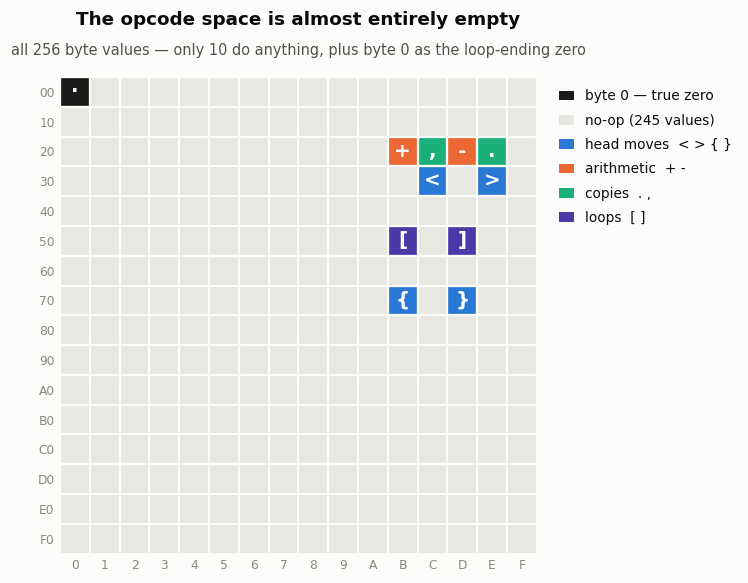

live opcodes: 10/256 = 3.9% of the byte space


In [24]:
fig, ax = plt.subplots(figsize=(8.2, 5.4))

grid = np.array([classify(b) for b in range(256)]).reshape(16, 16)
ax.imshow(grid, cmap=TAPE_CMAP, vmin=0, vmax=5, interpolation="nearest")

for b in range(256):
    r, c = divmod(b, 16)
    g = glyph(b)
    if g:
        ax.text(c, r, g, ha="center", va="center", fontsize=13,
                color="white", fontweight="bold")

ax.set_xticks(range(16)); ax.set_yticks(range(16))
ax.set_xticklabels([f"{i:X}" for i in range(16)], fontsize=8)
ax.set_yticklabels([f"{i:X}0" for i in range(16)], fontsize=8)
ax.set_xticks(np.arange(-.5, 16, 1), minor=True)
ax.set_yticks(np.arange(-.5, 16, 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=1.5)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title("The opcode space is almost entirely empty", pad=34)
ax.text(0.5, 1.045, "all 256 byte values — only 10 do anything, plus byte 0 as the loop-ending zero",
        transform=ax.transAxes, ha="center", fontsize=9.5, color=INK2)

handles = [Rectangle((0, 0), 1, 1, fc=ZERO_C), Rectangle((0, 0), 1, 1, fc=NOOP_C)] + \
          [Rectangle((0, 0), 1, 1, fc=FAMILY_C[k]) for k in ["move", "arith", "copy", "loop"]]
labels = ["byte 0 — true zero", "no-op (245 values)",
          "head moves  < > { }", "arithmetic  + -", "copies  . ,", "loops  [ ]"]
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.02, 1.0),
          frameon=False, fontsize=9, handlelength=1.1, labelspacing=0.75)
plt.tight_layout(); plt.show()

print(f"live opcodes: {len(OPS)}/256 = {len(OPS)/256:.1%} of the byte space")

### Why sparseness matters

Because instructions are this rare, a freshly randomised 64-byte tape holds only a
couple of live instructions. Two consequences follow:

1. **The soup starts out computationally silent.** Glue two random tapes together
   and, on average, only a handful of operations run before the pointer wanders off
   the end.
2. **That silence is what makes the transition legible.** It provides a quiet
   "pre-life" baseline against which the arrival of a replicator stands out as a
   step change.

Under a dense 4-bit encoding, every random tape would compute furiously from the
very first epoch — and there would be no baseline at all.

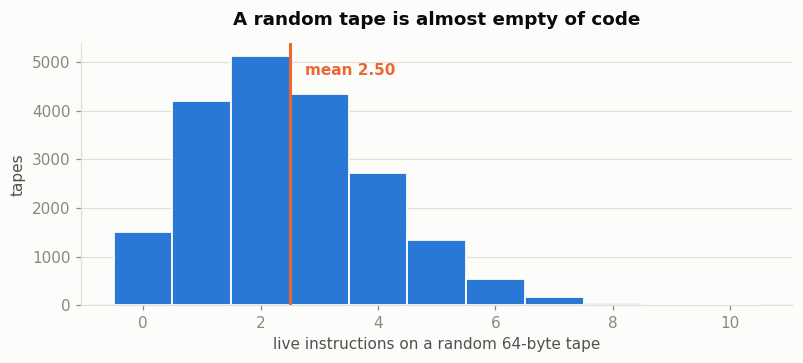

expected: 64 x 10/256 = 2.50 instructions per tape


In [25]:
rng = np.random.default_rng(0)
tapes = rng.integers(0, 256, (20000, TAPE), dtype=np.uint8)
live = np.isin(tapes, np.frombuffer(OPS.encode(), dtype=np.uint8)).sum(axis=1)

fig, ax = plt.subplots(figsize=(7.4, 3.4))
bins = np.arange(0, live.max() + 2) - 0.5
ax.hist(live, bins=bins, color=FAMILY_C["move"], edgecolor=SURFACE, linewidth=1.2)
ax.axvline(live.mean(), color=FAMILY_C["arith"], linewidth=2, zorder=5)
ax.text(live.mean() + 0.25, ax.get_ylim()[1] * 0.88,
        f"mean {live.mean():.2f}", color=FAMILY_C["arith"], fontweight="bold")
ax.set_xlabel("live instructions on a random 64-byte tape")
ax.set_ylabel("tapes")
ax.set_title("A random tape is almost empty of code")
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"expected: 64 x 10/256 = {64*10/256:.2f} instructions per tape")

---

# 2 · The replicator the authors found

In the paper's case study a self-replicator first appears at **epoch 2354**, and the
authors reconstruct it byte by byte. Written out — with `·` for zero bytes and
blanks for inert data — it is:

```
[[{.>]-]                                                ]-]>.{[[
```

### Two things stand out

1. **It is short.** Just 16 live instructions, adrift in a 64-byte tape.
2. **The tail is the head reversed.** That mirror symmetry is not decoration: the
   first half copies bytes outward, and the second half is what a copy of the
   program looks like once it has been written *backwards*. It is a recurring motif
   in the replicators this system discovers.

### Running it

Slot **A** holds the replicator, slot **B** holds a blank tape. This is the paper's
autocatalytic reaction `S + F → 2S`, where `F` is inert "food".

In [26]:
prog = bff.PAPER_REPLICATOR
food = bytes(TAPE)

tape = bytearray(prog + food)
trace = []
n_ops = bff.evaluate(tape, trace=trace)

print(f"A  in : |{render(prog)}|")
print(f"B  in : |{render(food)}|")
print(f"{'':7}{'-'*64}")
print(f"A' out: |{render(tape[:TAPE])}|")
print(f"B' out: |{render(tape[TAPE:])}|")
print()
print(f"executed {n_ops} operations over {len(trace)} characters read")
print(f"slot A unchanged : {bytes(tape[:TAPE]) == prog}")
print(f"slot B is a copy : {bytes(tape[TAPE:]) == prog}   <-- self-replication")

A  in : |[[{.>]-]                                                ]-]>.{[[|
B  in : |0000000000000000000000000000000000000000000000000000000000000000|
       ----------------------------------------------------------------
A' out: |[[{.>]-]                                                ]-]>.{[[|
B' out: |[[{.>]-]                                                ]-]>.{[[|

executed 8192 operations over 8192 characters read
slot A unchanged : True
slot B is a copy : True   <-- self-replication


## Watching the copy happen

The single most informative picture in this notebook. **How to read it:**

- **Time runs downward** — each row is one executed character.
- **The 128 tape positions run across.**
- **The heavy vertical rule at position 64** is the seam where tape A ends and
  tape B begins.
- **The three thin traces** are the instruction pointer and the two data heads.

Watch the right-hand half — solid black (all zeros) at the top — fill in with a
mirror of the left. The replicator drives `head1` steadily rightward across the
seam, copying as it goes.

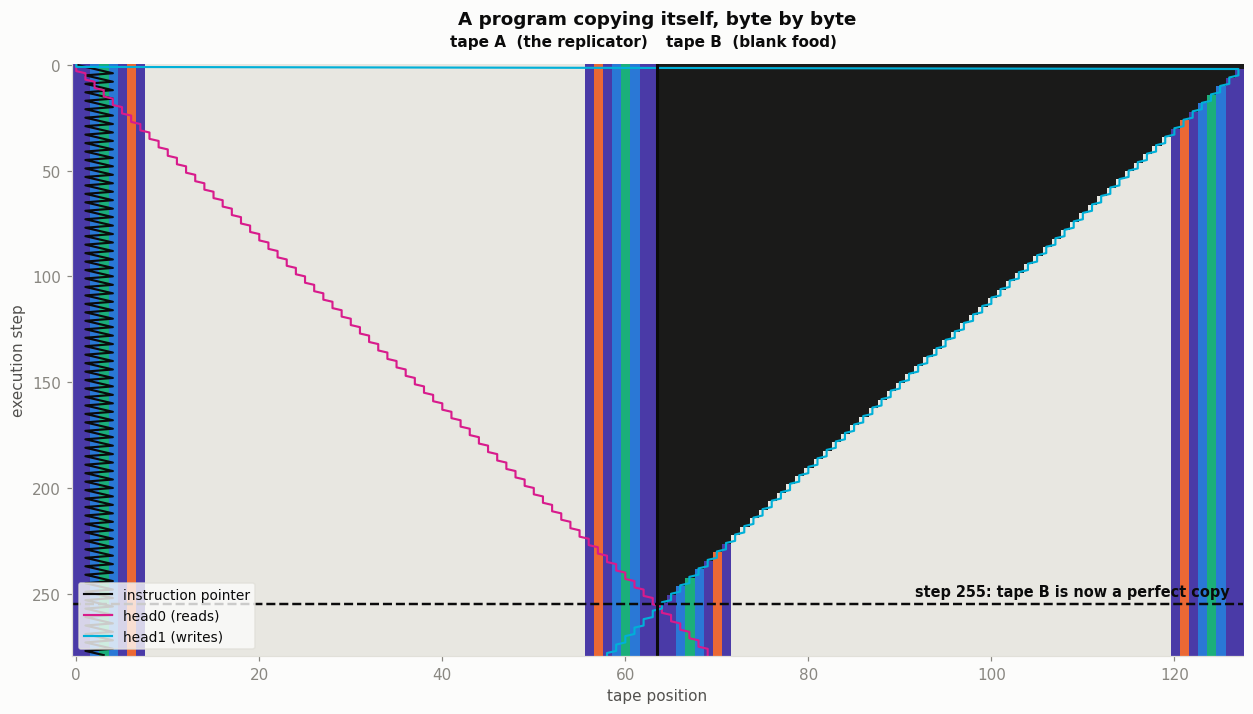

In [27]:
STEPS = 280
frames = np.stack([classify_row(e["tape"]) for e in trace[:STEPS]])

fig, ax = plt.subplots(figsize=(11.5, 6.6))
ax.imshow(frames, cmap=TAPE_CMAP, vmin=0, vmax=5,
          interpolation="nearest", aspect="auto")

steps = np.arange(STEPS)
ax.plot([e["pc"]    for e in trace[:STEPS]], steps, color=INK,   lw=1.4, label="instruction pointer")
ax.plot([e["head0"] for e in trace[:STEPS]], steps, color="#d81b8c", lw=1.4, label="head0 (reads)")
ax.plot([e["head1"] for e in trace[:STEPS]], steps, color="#00b0d8", lw=1.4, label="head1 (writes)")

ax.axvline(TAPE - 0.5, color=INK, lw=2)
ax.text(TAPE - 1.5, -9, "tape A  (the replicator)", ha="right", fontsize=10, color=INK, fontweight="bold")
ax.text(TAPE + 0.5, -9, "tape B  (blank food)",     ha="left",  fontsize=10, color=INK, fontweight="bold")

done = next(i for i, e in enumerate(trace) if e["tape"][TAPE:] == prog)
ax.axhline(done, color=INK, lw=1.6, ls="--")
ax.text(126, done - 4, f"step {done}: tape B is now a perfect copy",
        ha="right", fontsize=9.5, color=INK, fontweight="bold")

ax.set_xlabel("tape position"); ax.set_ylabel("execution step")
ax.set_title("A program copying itself, byte by byte", pad=26)
ax.legend(loc="lower left", frameon=True, facecolor=SURFACE, edgecolor=GRID, fontsize=9)
plt.tight_layout(); plt.show()

## Step through it yourself

Drag the slider to move through execution **one character at a time**. The markers
under the tape are:

| marker | meaning |
|:-:|:--|
| `^` | the instruction pointer |
| `0` | `head0` — reads |
| `1` | `head1` — writes |

In [29]:
def show_step(step=0):
    e = trace[step]
    t = e["tape"]
    chars = "".join(glyph(b) if glyph(b) else "·" if b == 0 else " " for b in t)
    marks = [" "] * len(t)
    for pos, ch in ((e["head0"], "0"), (e["head1"], "1"), (e["pc"], "^")):
        if 0 <= pos < len(t):
            marks[pos] = ch
    body = (f"<pre style='font-family:ui-monospace,Menlo,monospace;font-size:13px;"
            f"line-height:1.35;margin:0'>"
            f"{chars[:TAPE]}<span style='color:#c3c2b7'>|</span>{chars[TAPE:]}\n"
            f"{''.join(marks[:TAPE])}<span style='color:#c3c2b7'>|</span>{''.join(marks[TAPE:])}</pre>")
    op = e["cmd"] or "· (no-op)"
    head = (f"<div style='font-family:system-ui;font-size:13px;margin-bottom:6px'>"
            f"step <b>{step}</b> &nbsp; executing <b>{op}</b> &nbsp; "
            f"pc={e['pc']} &nbsp; head0={e['head0']} &nbsp; head1={e['head1']}</div>")
    display(HTML(head + body))

W.interact(show_step,
           step=W.IntSlider(min=0, max=STEPS - 1, step=1, value=0,
                            description="step", continuous_update=False,
                            layout=W.Layout(width="700px")));

interactive(children=(IntSlider(value=0, continuous_update=False, description='step', layout=Layout(width='700…

---

# 3 · The soup

Now the actual experiment. **The rule, in full:**

1. Fill `N` tapes of 64 bytes with **uniform random noise**.
2. Shuffle, then pair the tapes off. For each pair `(A, B)`:
   - concatenate to 128 bytes,
   - run it,
   - split back into two 64-byte tapes,
   - return both to the soup.
3. *Optionally* flip a random byte here and there — the default background mutation
   rate is `1/4096` per byte per epoch.

That is everything. The transition happens **with or without step 3**, and there is
no explicit fitness function anywhere: programs are simply left to execute and
overwrite each other.

## Measuring "aliveness"

Progress is tracked with the paper's **high-order entropy**:

> the Shannon entropy of the soup's bytes **minus** its compressed size in bits per
> byte

Intuitively, it captures the information that can only be explained by *relations
between* characters, rather than by the byte distribution alone. It is constructed
so that:

| soup | Shannon entropy | compressibility | **high-order entropy** |
|:--|:--|:--|:--|
| **uniform noise** | high | incompressible | **≈ 0** — the terms cancel |
| **many copies of one program** | still varied | highly compressible | **well above 1** |

The authors approximate Kolmogorov complexity with `brotli -q2` — the standard
practice of using an LZ-style compressor as a stand-in.

Let us sanity-check both ends of that table:

In [30]:
demo_n = 512
noise    = np.random.default_rng(1).integers(0, 256, (demo_n, TAPE), dtype=np.uint8)
one_prog = np.tile(np.frombuffer(bff.PAPER_REPLICATOR, dtype=np.uint8), (demo_n, 1))
half     = np.concatenate([noise[:demo_n//2], one_prog[demo_n//2:]])

for name, soup_arr in [("uniform noise", noise),
                       ("half noise, half replicator", half),
                       ("all one replicator", one_prog)]:
    print(f"{name:<32} high-order entropy = {high_order_entropy(soup_arr.tobytes()):6.3f}")

uniform noise                    high-order entropy = -0.007
half noise, half replicator      high-order entropy =  1.625
all one replicator               high-order entropy =  1.425


## Start it

Set the knobs and press **Run until transition**.

- **Defaults:** 4096 tapes, seed 4 — known to cross over around **epoch 8750**,
  taking roughly **25 seconds**.
- **Most seeds never transition** within the epoch budget. In the paper only ~40% of
  runs do so within 16k epochs, so **a run that ends flat is a normal result, not a
  bug**. Press the button again with a different seed.
- **Untick `background mutation`** to confirm the effect survives with pure
  self-modification and no noise at all.

In [32]:
out       = W.Output()
n_w       = W.Dropdown(options=[1024, 2048, 4096, 8192], value=4096, description="tapes")
seed_w    = W.IntText(value=4, description="seed", layout=W.Layout(width="160px"))
mut_w     = W.Checkbox(value=True, description="background mutation")
maxep_w   = W.IntText(value=20000, description="max epochs", layout=W.Layout(width="200px"))
run_btn   = W.Button(description="Run until transition", button_style="success",
                     icon="play", layout=W.Layout(width="200px"))
state     = {}

def _plot(hist, transition):
    ep = [h[0] for h in hist]; cx = [h[1] for h in hist]; op = [h[2] for h in hist]
    fig, axes = plt.subplots(2, 1, figsize=(9.6, 6.0), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    a0, a1 = axes
    a0.plot(ep, cx, color=FAMILY_C["move"], lw=1.8)
    a0.axhline(1.0, color=MUTED, lw=1, ls=":")
    a0.text(ep[0], 1.06, "complexity 1.0", fontsize=8.5, color=MUTED)
    a0.set_ylabel("high-order entropy")
    a0.set_title("Pre-life, then life", loc="left")
    a1.plot(ep, op, color=FAMILY_C["arith"], lw=1.6)
    a1.set_ylabel("ops / interaction"); a1.set_xlabel("epoch")
    for a in axes:
        a.yaxis.grid(True); a.set_axisbelow(True)
        if transition:
            a.axvline(transition, color=INK, lw=1.4, ls="--")
    if transition:
        a0.text(transition, a0.get_ylim()[1]*0.94, f"  transition @ {transition}",
                fontsize=9.5, fontweight="bold", color=INK)
    plt.tight_layout(); plt.show()

def run_soup(n, seed, mutate, max_epochs, bar=None):
    soup = Soup(n, seed=seed, mutation_prob=(1/4096) if mutate else 0.0)
    hist, transition = [], None
    while soup.epoch < max_epochs:
        ops = soup.step()
        if soup.epoch % 100 == 0:
            c = soup.complexity()
            hist.append((soup.epoch, c, ops / (soup.n / 2)))
            if bar is not None:
                bar.value = soup.epoch
                bar.description = f"e{soup.epoch} c={c:.2f}"
            if c >= 1.0:
                transition = soup.epoch
                break
    return soup, hist, transition

def on_run(_):
    out.clear_output(wait=True)
    with out:
        t0 = time.time()
        bar = W.IntProgress(min=0, max=maxep_w.value, description="running",
                            layout=W.Layout(width="500px"))
        display(bar)
        soup, hist, transition = run_soup(n_w.value, seed_w.value,
                                          mut_w.value, maxep_w.value, bar)
        bar.bar_style = "success" if transition else "warning"
        state["soup"], state["hist"], state["transition"] = soup, hist, transition
        print(f"ran {soup.epoch} epochs in {time.time()-t0:.1f}s")
        if transition:
            print(f"*** STATE TRANSITION at epoch {transition} "
                  f"(complexity {soup.complexity():.2f}) ***")
        else:
            print(f"no transition (complexity {soup.complexity():.3f}) — "
                  f"normal; try another seed")
        _plot(hist, transition)

def ensure_soup():
    """Let the cells below work whether you pressed the button or hit Run All."""
    if "soup" not in state:
        print("no interactive run yet — running the known-good seed 4 (~25 s) ...")
        soup, hist, transition = run_soup(4096, 4, True, 20000)
        state["soup"], state["hist"], state["transition"] = soup, hist, transition
        print(f"done: epoch {soup.epoch}, complexity {soup.complexity():.2f}")
    return state["soup"]

run_btn.on_click(on_run)
display(W.VBox([W.HBox([n_w, seed_w, maxep_w]), W.HBox([mut_w, run_btn]), out]))

## What just happened

Run the cell below once the soup has transitioned. It puts the two regimes side by
side as images, where **every row is one tape** and **every column a byte position**:

- **Before** — television static.
- **After** — *striped*: the same program, at slightly different offsets, over and
  over.

That horizontal smearing is the signature of replicators copying themselves at an
offset **other than exactly 64** — which turns out to matter a great deal in §4.

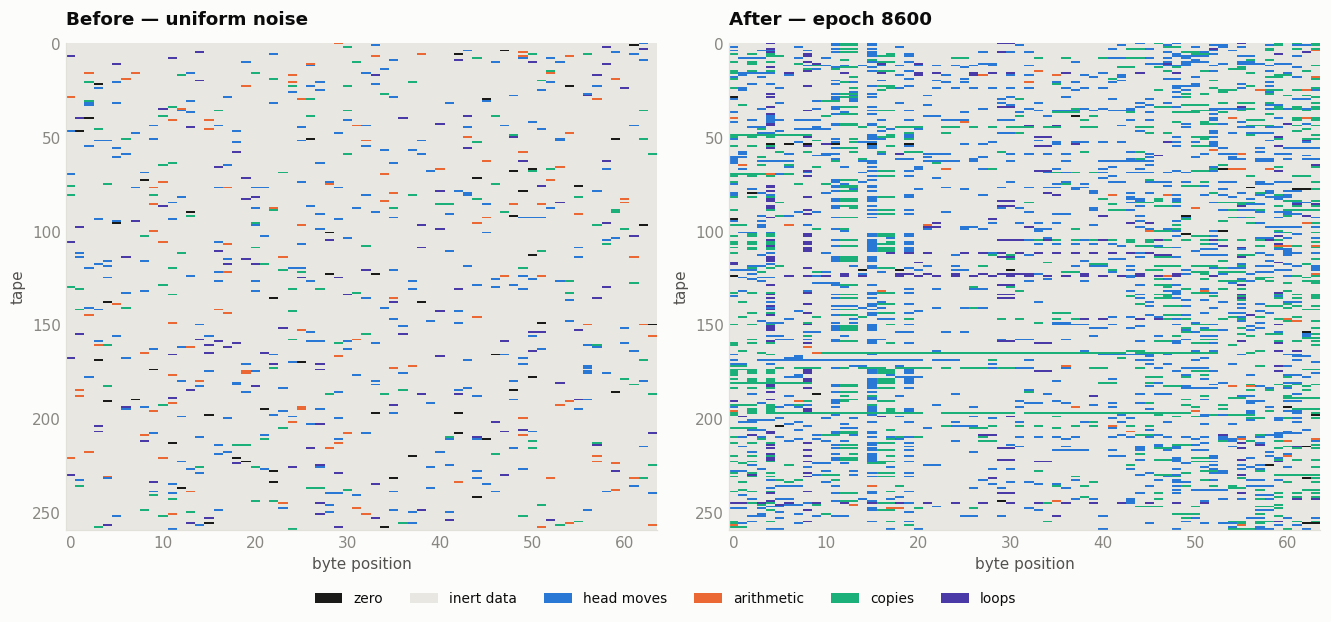

most common 16-byte cores in the soup:
  x1121  |  <,, }         |
  x1096  | <,, }          |
  x1051  |<,, }           |


In [33]:
soup = ensure_soup()

sample = 260
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.4))

before = np.random.default_rng(7).integers(0, 256, (sample, TAPE), dtype=np.uint8)
after  = soup.tapes()[:sample]

for ax, data, title in [(axes[0], before, "Before — uniform noise"),
                        (axes[1], after,  f"After — epoch {soup.epoch}")]:
    img = np.stack([classify_row(row) for row in data])
    ax.imshow(img, cmap=TAPE_CMAP, vmin=0, vmax=5, interpolation="nearest", aspect="auto")
    ax.set_title(title, loc="left")
    ax.set_xlabel("byte position"); ax.set_ylabel("tape")
    ax.tick_params(length=0)

handles = [Rectangle((0,0),1,1, fc=ZERO_C), Rectangle((0,0),1,1, fc=NOOP_C)] + \
          [Rectangle((0,0),1,1, fc=FAMILY_C[k]) for k in ["move","arith","copy","loop"]]
fig.legend(handles, ["zero","inert data","head moves","arithmetic","copies","loops"],
           loc="lower center", ncol=6, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(); plt.show()

print("most common 16-byte cores in the soup:")
for kmer, count in dominant_kmer(soup.tapes(), k=16, top=3):
    print(f"  x{count:<5} |{render(kmer)}|")

---

# 4 · Is it *really* a replicator?

Dominating the soup is **not** proof of self-replication. It could simply be
whatever the soup happened to decay into.

The decisive test is the paper's *seeded* experiment:

> Drop a few copies into a **fresh** soup of pure noise, and see whether they spread.

## Two traps

Both of these produce plausible-looking **wrong answers**, and both cost real
debugging time here.

### Trap 1 — exact whole-tape matching finds nothing

The paper warns that a replicator is usually much smaller than the 64-byte window.
One that copies itself at an offset ≠ 64 replicates perfectly well while **never**
producing an exact full-tape copy. Measured that way, the dominant tapes above score
**0%**. Counting shared *substrings* instead finds them immediately.

### Trap 2 — `render()` is not injective

It draws every non-opcode byte as a blank, so two cores can look **byte-identical on
screen** while their filler bytes differ entirely. Any probe must therefore run on
raw bytes, never on the rendered string.

> An earlier version of this analysis reported **0% carriers at epoch 0** for tapes
> it had *just injected* — purely because of trap 2.

## The design that avoids both

- **Probe** with a 16-byte core taken from the winning tape *itself*.
- **Control** by running a random tape through the identical procedure.

probe core |  <,, }         |  present in 27.4% of tapes



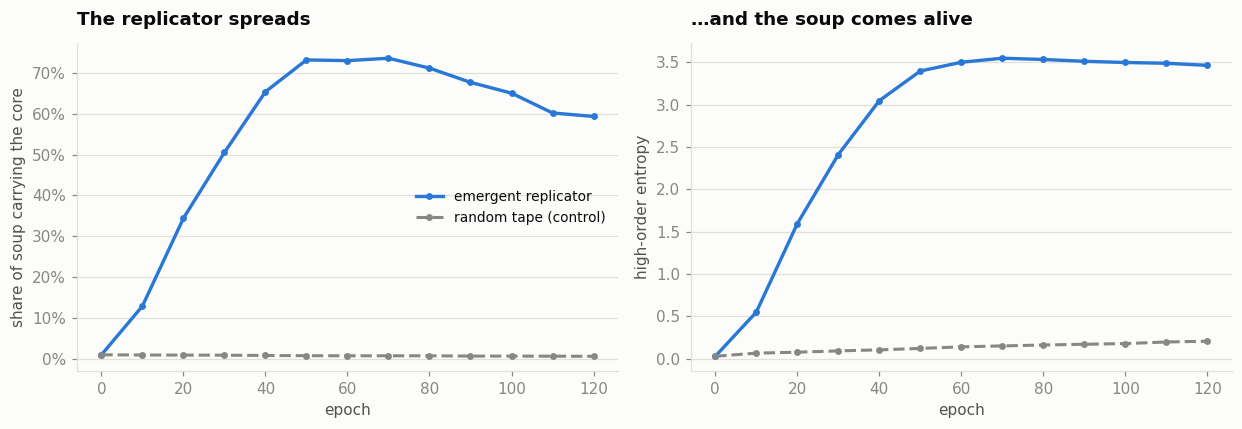

replicator core : 1.0% -> 59.4%   complexity 0.03 -> 3.46
random control  : 1.0% -> 0.6%   complexity 0.03 -> 0.21


In [34]:
soup = ensure_soup()

winner = soup.most_common(1)[0][0]
tapes  = soup.tapes()

def carrying(arr, kmer):
    return sum(1 for r in arr if kmer in bytes(r)) / len(arr)

# most widespread 16-mer that actually occurs in the winning tape
cands = {winner[i:i+16]: carrying(tapes, winner[i:i+16]) for i in range(TAPE - 15)}
kmer  = max(cands, key=cands.get)
print(f"probe core |{render(kmer)}|  present in {cands[kmer]:.1%} of tapes\n")

def spread(probe_tape, probe_kmer, seed, epochs=120, every=10):
    fresh = Soup(soup.n, seed=seed)
    arr   = fresh.tapes()
    inject = max(1, fresh.n // 100)
    for i in np.random.default_rng(seed).choice(fresh.n, inject, replace=False):
        arr[i] = np.frombuffer(probe_tape, dtype=np.uint8)
    hist = [(0, carrying(fresh.tapes(), probe_kmer), fresh.complexity())]
    for _ in range(epochs):
        fresh.step()
        if fresh.epoch % every == 0:
            hist.append((fresh.epoch, carrying(fresh.tapes(), probe_kmer),
                         fresh.complexity()))
    return hist

rep_hist  = spread(winner, kmer, seed=soup.n + 11)
ctrl_tape = np.random.default_rng(3).integers(0, 256, TAPE, dtype=np.uint8).tobytes()
ctrl_hist = spread(ctrl_tape, ctrl_tape[16:32], seed=soup.n + 11)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
for ax, idx, ylab, title in [(axes[0], 1, "share of soup carrying the core",
                              "The replicator spreads"),
                             (axes[1], 2, "high-order entropy",
                              "…and the soup comes alive")]:
    ax.plot([h[0] for h in rep_hist], [h[idx] for h in rep_hist],
            color=FAMILY_C["move"], lw=2.2, marker="o", ms=3.5, label="emergent replicator")
    ax.plot([h[0] for h in ctrl_hist], [h[idx] for h in ctrl_hist],
            color=MUTED, lw=2.0, ls="--", marker="o", ms=3.5, label="random tape (control)")
    ax.set_xlabel("epoch"); ax.set_ylabel(ylab); ax.set_title(title, loc="left")
    ax.yaxis.grid(True); ax.set_axisbelow(True)
axes[0].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print(f"replicator core : {rep_hist[0][1]:.1%} -> {rep_hist[-1][1]:.1%}   "
      f"complexity {rep_hist[0][2]:.2f} -> {rep_hist[-1][2]:.2f}")
print(f"random control  : {ctrl_hist[0][1]:.1%} -> {ctrl_hist[-1][1]:.1%}   "
      f"complexity {ctrl_hist[0][2]:.2f} -> {ctrl_hist[-1][2]:.2f}")

### Reading the result

- **The emergent program spreads** from 1% into a large fraction of a soup it has
  never seen, dragging complexity up two orders of magnitude with it.
- **The random control, injected identically, decays.**

The core never quite reaches 100%, and *that is itself informative*: the family
keeps drifting, so variants shift position and mutate away from any fixed 16-byte
probe. The **complexity curve is the better measure** of how completely the soup has
been taken over — and it saturates.

---

# 5 · Where this goes

Four threads worth pulling on, all from the paper.

### Mutation is not the driver

Turn background noise off entirely (untick the box above) and replicators still
arise. The authors found the no-noise variant *more* likely to transition — around
50%. **Self-modification does the work; random mutation is a sideshow.**

### It is not about Brainfuck

The same transition appears in Forth variants, and in emulators of real **Z80** and
**Intel 8080** CPUs.

### There is a counterexample

In `SUBLEQ` they could not make it happen, despite significant effort. Their
suspicion: the shortest possible self-replicator in that language is simply **too
long to stumble upon** by chance.

### Space changes the story

Arrange tapes on a 2D grid so they interact only with neighbours, and replicators
spread as a **wavefront** rather than instantly — which lets rival lineages coexist
and compete.

---

## Reproducing from the command line

```sh
python3 bff.py --selfrep                    # the paper's replicator vs a blank tape
python3 soup.py --n 4096 --seed 4 --csv run.csv
python3 soup.py --no-mutation               # self-modification only
python3 takeover.py --seed 4                # seeded takeover test, with control
```

## Further reading

- The paper's LaTeX source is in **`../AgueraYArcas/`**.
- **`README.md`** in this folder documents the implementation and exactly how it was
  validated against the paper.
- The authors' reference implementation:
  [paradigms-of-intelligence/cubff](https://github.com/paradigms-of-intelligence/cubff).